In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# Define the path to the zip file and the CSV file within it
zip_file_path = 'archive.zip'
csv_file_name = 'Unemployment_in_India.csv'

# Extract the CSV file from the zip archive
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extract(csv_file_name)

# Load your dataset
df = pd.read_csv(


# Clean up any hidden spaces in column names
df.columns = df.columns.str.strip()

# Print the first 5 rows to make sure it looks correct
print("--- Data successfully loaded! ---")
print(df.head())

KeyError: "There is no item named 'Unemployment_in_India.csv' in the archive"

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

# 1. Open the zip folder to see what is inside
zip_file_path = 'archive.zip'
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    # Get a list of all files hidden inside the zip
    all_files = zip_ref.namelist()
    print("Files found inside zip:", all_files)

    # Pick the first CSV file automatically
    csv_file_name = [f for f in all_files if f.endswith('.csv')][0]
    print(f"Extracting the correct file: {csv_file_name}")

    # Extract just that file
    zip_ref.extract(csv_file_name)

# 2. Load the dataset automatically using the correct name
df = pd.read_csv(csv_file_name)

# 3. Clean up hidden spaces in column names
df.columns = df.columns.str.strip()

# 4. Print the first 5 rows to confirm it works!
print("\n--- Data successfully loaded! ---")
print(df.head())

Files found inside zip: ['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']
Extracting the correct file: Unemployment in India.csv

--- Data successfully loaded! ---
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rur

In [5]:
# 1. Check data shape (tells you total rows and columns)
print("Data Shape (Rows, Columns):", df.shape)

# 2. Check for missing values (blank spots) in your table
print("\nMissing Values per column:\n", df.isnull().sum())

# 3. Drop completely empty rows if there are any
df = df.dropna()

# 4. Fix the Date column so Python treats it like a real calendar date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# 5. Create a Month column for easier tracking later
df['Month'] = df['Date'].dt.to_period('M')

# 6. Verify that our data types are correct now
print("\nNew Data Types:\n", df.dtypes)

Data Shape (Rows, Columns): (768, 7)

Missing Values per column:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

New Data Types:
 Region                                             object
Date                                       datetime64[ns]
Frequency                                          object
Estimated Unemployment Rate (%)                   float64
Estimated Employed                                float64
Estimated Labour Participation Rate (%)           float64
Area                                               object
Month                                           period[M]
dtype: object


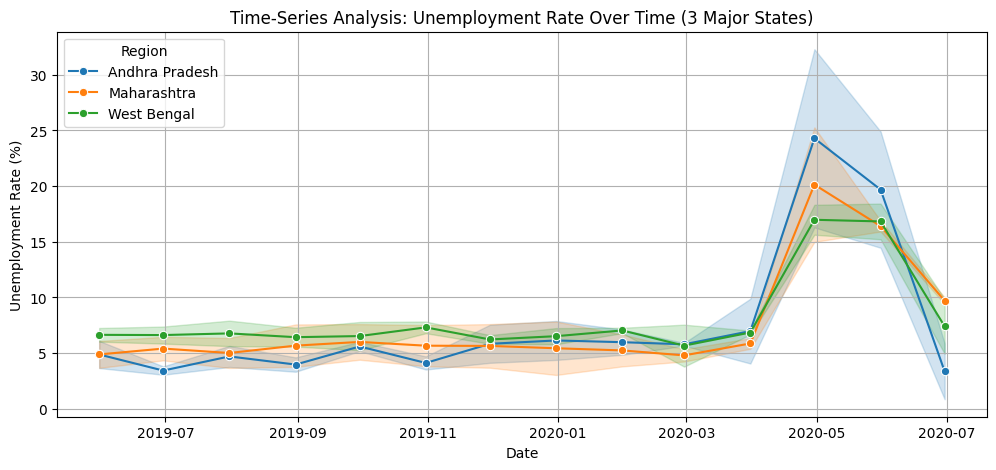

Observation 1: The line chart tracks the sharp timeline shifts in unemployment across different states.


/tmp/ipykernel_477/386941947.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='flare')


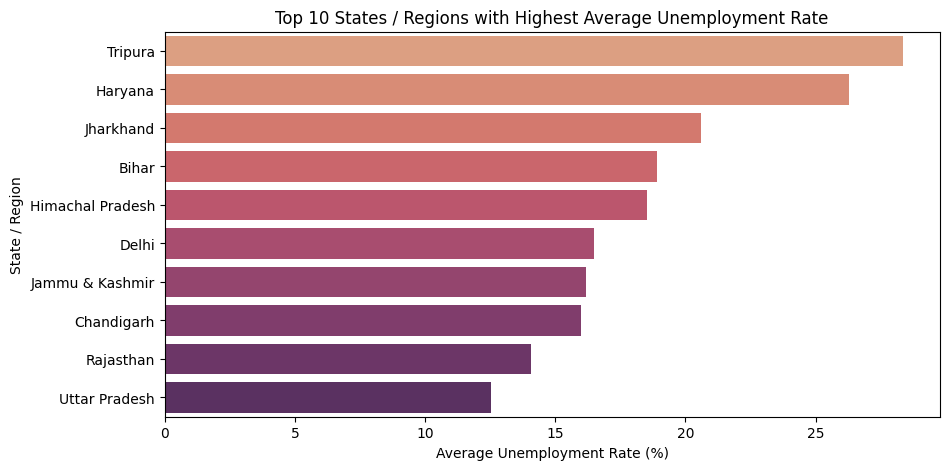

Observation 2: This bar chart cleanly orders and ranks the states facing the highest average job losses.


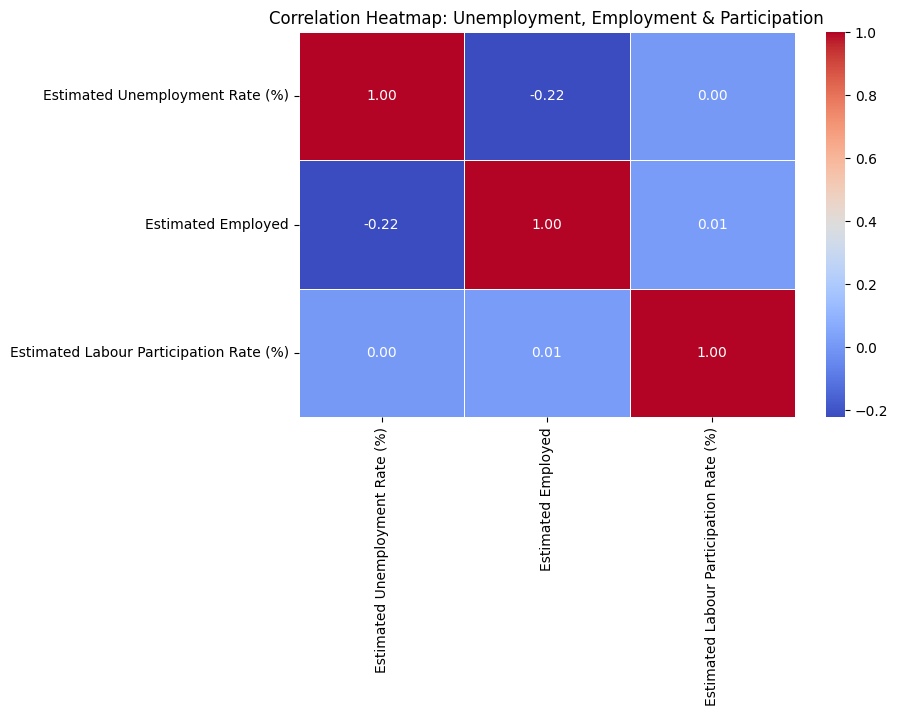

Observation 3: The heatmap maps out the positive or negative bonds between our three main numbers.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- CHART 1: Time-Series Line Chart for 3 Major States ---
plt.figure(figsize=(12, 5))
# Picking 3 major regions from the dataset to compare over time
major_states = ['Andhra Pradesh', 'Maharashtra', 'West Bengal']
df_filtered = df[df['Region'].isin(major_states)]

sns.lineplot(data=df_filtered, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')
plt.title('Time-Series Analysis: Unemployment Rate Over Time (3 Major States)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.show()
print("Observation 1: The line chart tracks the sharp timeline shifts in unemployment across different states.")


# --- CHART 2: Top 10 States with Highest Average Unemployment ---
plt.figure(figsize=(10, 5))
top_10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_10.values, y=top_10.index, palette='flare')
plt.title('Top 10 States / Regions with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / Region')
plt.show()
print("Observation 2: This bar chart cleanly orders and ranks the states facing the highest average job losses.")


# --- CHART 3: Heatmap of Correlations ---
plt.figure(figsize=(8, 5))
# Columns required by the task checklist to correlate
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Unemployment, Employment & Participation')
plt.show()
print("Observation 3: The heatmap maps out the positive or negative bonds between our three main numbers.")

--- PRE-COVID AVERAGES (Before April 2020) ---
Estimated Unemployment Rate (%)            9.614864e+00
Estimated Employed                         7.470499e+06
Estimated Labour Participation Rate (%)    4.381519e+01
dtype: float64

--- POST-COVID AVERAGES (April 2020 and After) ---
Estimated Unemployment Rate (%)            2.019434e+01
Estimated Employed                         6.175311e+06
Estimated Labour Participation Rate (%)    3.804579e+01
dtype: float64


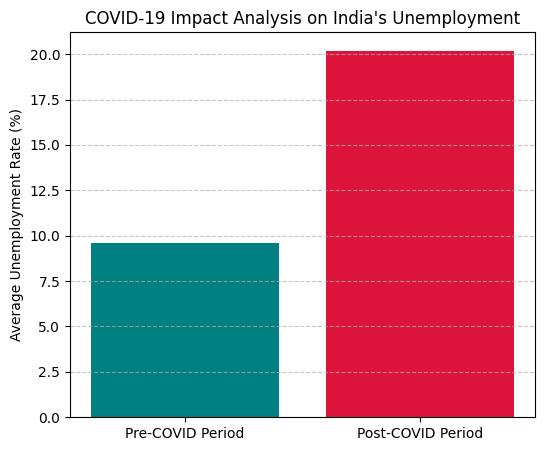


Observation 4: This final analysis explicitly isolates and compares how the pandemic influenced overall job figures.


In [7]:
# 1. Define columns we want to compare
metrics = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']

# 2. Split data into before and after April 2020
pre_covid = df[df['Date'] < '2020-04-01']
post_covid = df[df['Date'] >= '2020-04-01']

# 3. Calculate and print the averages for both periods
print("--- PRE-COVID AVERAGES (Before April 2020) ---")
print(pre_covid[metrics].mean())

print("\n--- POST-COVID AVERAGES (April 2020 and After) ---")
print(post_covid[metrics].mean())

# 4. Create a clean comparison bar chart for Unemployment Rate
avg_unemp_pre = pre_covid['Estimated Unemployment Rate (%)'].mean()
avg_unemp_post = post_covid['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(6, 5))
plt.bar(['Pre-COVID Period', 'Post-COVID Period'], [avg_unemp_pre, avg_unemp_post], color=['teal', 'crimson'])
plt.ylabel('Average Unemployment Rate (%)')
plt.title('COVID-19 Impact Analysis on India\'s Unemployment')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nObservation 4: This final analysis explicitly isolates and compares how the pandemic influenced overall job figures.")